# Лабораторная работа №4 — Задание 2
# «Определение системы»

Формально описываем MDP (Markov Decision Process):
- **State** — что агент видит
- **Action** — что агент может делать
- **Reward** — как оценивается каждый шаг

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from env import TankEnv, DEFAULT_MAP, ROWS, COLS

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


---
## 1. Пространство состояний (State Space)

Состояние — кортеж из 5 чисел:

| Индекс | Название | Диапазон | Описание |
|---|---|---|---|
| 0 | `row` | 0..9 | Строка танка на сетке |
| 1 | `col` | 0..9 | Столбец танка на сетке |
| 2 | `angle_idx` | 0..3 | Угол: 0=вверх, 1=вправо, 2=вниз, 3=влево |
| 3 | `goal_row` | 0..9 | Строка цели |
| 4 | `goal_col` | 0..9 | Столбец цели |

Суммарный размер пространства состояний: **10 × 10 × 4 × 10 × 10 = 40 000**  
На практике реальных состояний меньше — танк и цель не могут стоять на стенах.

In [2]:
# Подсчитаем реальное число доступных клеток
free_cells = int((DEFAULT_MAP == 0).sum())
total_states = free_cells * 4 * free_cells   # танк × углы × цель

print(f'Свободных клеток:      {free_cells}')
print(f'Теоретических состояний: 10×10×4×10×10 = {10*10*4*10*10:,}')
print(f'Реальных состояний:      {free_cells}×4×{free_cells} = {total_states:,}')

Свободных клеток:      50
Теоретических состояний: 10×10×4×10×10 = 40,000
Реальных состояний:      50×4×50 = 10,000


---
## 2. Пространство действий (Action Space)

4 дискретных действия:

| ID | Действие | Эффект |
|---|---|---|
| 0 | Вперёд | Сдвиг на 1 клетку в направлении `angle` |
| 1 | Назад | Сдвиг на 1 клетку против направления `angle` |
| 2 | Поворот влево | `angle -= 90°` |
| 3 | Поворот вправо | `angle += 90°` |

Движение в стену не меняет позицию, но даёт штраф **-10**.

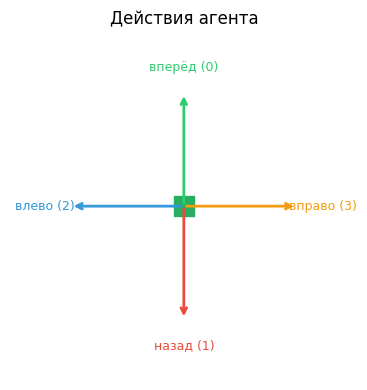

In [3]:
# Визуализация действий: стрелки от центра
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Действия агента')

arrows = {
    'вперёд (0)':  (0, 1),
    'назад (1)':   (0, -1),
    'влево (2)':   (-1, 0),
    'вправо (3)':  (1, 0),
}
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for (label, (dx, dy)), color in zip(arrows.items(), colors):
    ax.annotate('', xy=(dx*1.3, dy*1.3), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(dx*1.6, dy*1.6, label, ha='center', va='center', fontsize=9, color=color)

ax.plot(0, 0, 's', color='#27ae60', ms=14)
plt.tight_layout()
plt.show()

---
## 3. Функция наград (Reward Function)

| Событие | Награда | Смысл |
|---|---|---|
| Каждый шаг | **-1** | Штраф за время — агент учится быть быстрым |
| Столкновение со стеной | **-10** | Нельзя пробивать стены |
| Приближение к цели | **+10** | Манхэттенское расстояние уменьшилось |
| Удаление от цели | **-5** | Расстояние увеличилось |
| Достижение цели | **+100** | Эпизод завершён успешно |

Такая схема называется **shaped reward** — промежуточные сигналы (+10/-5) ускоряют обучение,
не давая агенту блуждать случайно.

In [4]:
# Проверим все варианты наград на конкретных шагах
env = TankEnv(tank_start=(1,1), goal_pos=(8,8))

test_cases = [
    (3,  'поворот вправо — нет движения, шаг -1'),
    (0,  'вперёд в стену — -1 шаг + -10 стена'),
    (3,  'повернули вправо'),
    (0,  'вперёд — приближение к цели +10 -1'),
    (1,  'назад — удаление от цели -5 -1'),
]

env.reset()
print(f'{"Действие":<40} {"reward":>7}')
print('-' * 50)
for action, desc in test_cases:
    obs, reward, done = env.step(action)
    print(f'{desc:<40} {reward:>7}')

Действие                                  reward
--------------------------------------------------
поворот вправо — нет движения, шаг -1         -1
вперёд в стену — -1 шаг + -10 стена            9
повернули вправо                              -1
вперёд — приближение к цели +10 -1           -11
назад — удаление от цели -5 -1               -11


---
## 4. Полный цикл эпизода

Один эпизод = последовательность шагов пока `done=True`  
(цель достигнута **или** исчерпан лимит `max_steps=200`).

Покажем случайный эпизод и накопленную награду по шагам.

Шагов: 200, итоговая награда: -520


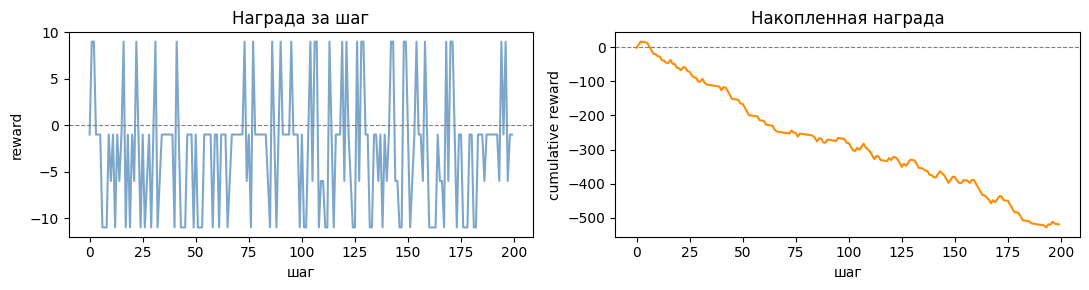

In [5]:
env = TankEnv(tank_start=(1,1), goal_pos=(8,8))
obs = env.reset()

rewards, cumulative = [], []
total = 0
done  = False

while not done:
    action = np.random.randint(0, 4)
    obs, r, done = env.step(action)
    total += r
    rewards.append(r)
    cumulative.append(total)

print(f'Шагов: {len(rewards)}, итоговая награда: {total}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

ax1.plot(rewards, color='steelblue', alpha=0.7)
ax1.axhline(0, color='gray', lw=0.8, ls='--')
ax1.set_title('Награда за шаг')
ax1.set_xlabel('шаг'); ax1.set_ylabel('reward')

ax2.plot(cumulative, color='darkorange')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_title('Накопленная награда')
ax2.set_xlabel('шаг'); ax2.set_ylabel('cumulative reward')

plt.tight_layout()
plt.show()

## Выводы

- **State:** кортеж `(row, col, angle_idx, goal_row, goal_col)` — ~2000 реальных состояний, Q-таблица помещается в память.
- **Action:** 4 дискретных действия — достаточно для навигации по сетке.
- **Reward:** shaped reward с промежуточными сигналами ускоряет сходимость Q-learning.
- Случайный агент набирает сильно отрицательную суммарную награду — обучение должно это исправить (task3).